In [10]:
import os
import pandas as pd
import chardet
from collections import defaultdict
import json

folder_path = "LinkedIn Data Public"

# Step 1: Track all files and names inside each file
file_to_names = dict()

for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder_path, filename)
        try:
            # Detect encoding
            with open(file_path, 'rb') as f:
                result = chardet.detect(f.read())
            encoding = result['encoding']

            # Read the file
            df = pd.read_csv(file_path, encoding=encoding, on_bad_lines='skip')
            df.columns = df.columns.str.strip().str.lower()
            if 'name' not in df.columns:
                continue

            # Get owner name (without .csv)
            owner = filename.rsplit('.', 1)[0].strip()

            # Clean names from 'name' column
            connections = df['name'].dropna().astype(str).str.strip()
            cleaned = [name for name in connections if name]
            file_to_names[owner] = cleaned

        except Exception as e:
            print(f"⚠️ Error reading {filename}: {e}")

# Step 2: Build adjacency list
adjacency = defaultdict(set)
processed = set()  # to avoid re-processing names

# First pass: Add file owners and their connections
for owner, connections in file_to_names.items():
    for conn in connections:
        adjacency[owner].add(conn)
        adjacency[conn].add(owner)

# Second pass: For names with no file, but appear in others
all_names_in_files = set()
for names in file_to_names.values():
    all_names_in_files.update(names)

for name in all_names_in_files:
    if name in file_to_names or name in processed:
        continue  # skip if this name has a file or already handled

    # Find all owners who mentioned this name
    connections = [owner for owner, names in file_to_names.items() if name in names]
    for conn in connections:
        adjacency[name].add(conn)
        adjacency[conn].add(name)

    processed.add(name)

# Convert sets to sorted lists
final_adjacency = {k: sorted(list(v)) for k, v in adjacency.items()}

#  Print result in console
print("\n Adjacency List (Final Output):")
for person, connections in final_adjacency.items():
    print(f"{person}: {connections}")

#  Save to JSON
with open("adjacency_list.json", "w", encoding="utf-8") as f:
    json.dump(final_adjacency, f, indent=2, ensure_ascii=False)

print("\nAdjacency list saved to 'adjacency_list.json'")



 Adjacency List (Final Output):
Shivang Dubey: ['ABANI SINGHA', 'ABHAY MAJHI', 'ABHISHEK CHAUDHARY', 'ABHISHEK GUPTA', 'ADITI AGNIHOTRI', 'ADITI CHOUHAN', 'ADITYA SHARMA', 'AISWARYA SINI LAL', 'AJEET KUMAR', 'AJIT KUMAR', 'AMAR DEEP', 'ANITA RAWAT', 'ANSH BIRE', 'ANSHITA MISHRA', 'ANSHU KALYAN', 'ANSHU _', 'ANUSHIKA UMARVAISHYA', 'ARUSHI TIWARI', 'ARYAN PATIDAR', 'ASHWANI DONGRE', 'Aadi Chandra', 'Aadi Malhotra', 'Aaditya Raj', 'Aakanksha Agarwal', 'Aakash Deep', 'Aakash Kumar', 'Aakash Pushpesh', 'Aakash Singh Bagiyal', 'Aamir Shabir', 'Aaqib Alaie', 'Aarti Patil', 'Aaryan Kuntal', 'Aashanvit Janbandhu', 'Aastha .', 'Aastha Singh Gaur', 'Aayush Sharma', 'Aayush Verma', 'Abdul Hadiee', 'Abdul Kadir', 'Abdullah Habib', 'Abhay Kumar', 'Abhay Tiwari', 'Abhijit Gautam', 'Abhimanyu Kumar', 'Abhinam Dutta', 'Abhinav Kumar', 'Abhinav Raj', 'Abhinav Singh', 'Abhinav Soni', 'Abhinit Singh', 'Abhishek Choudhary', 'Abhishek Jaiswal', 'Abhishek Kumar', 'Abhishek Kumar Saxena', 'Abhishek Kumar pas

In [11]:
len(final_adjacency)

29290

In [12]:
import json

# Load existing adjacency list
with open("adjacency_list.json", "r", encoding="utf-8") as f:
    adjacency_data = json.load(f)

# Build node count dictionary
node_counts = {person: len(connections) for person, connections in adjacency_data.items()}

# Print the node counts
print("\n Node Counts (Number of connections for each person):")
for person, count in node_counts.items():
    print(f"{person}: {count}")

# Optional: Save to a separate JSON file
with open("node_counts.json", "w", encoding="utf-8") as f:
    json.dump(node_counts, f, indent=2, ensure_ascii=False)

print("\n Node count saved to 'node_counts.json'")



 Node Counts (Number of connections for each person):
Shivang Dubey: 1539
Aadi Chandra: 20
Aadi Malhotra: 12
Aaditya Raj: 280
Aakanksha Agarwal: 18
Aakash Deep: 88
Aakash Kumar: 111
Aakash Pushpesh: 13
Aakash Singh Bagiyal: 1
Aamir Shabir: 1
Aaqib Alaie: 2
Aarti Patil: 99
Aaryan Kuntal: 1
Aashanvit Janbandhu: 40
Aastha .: 2
Aastha Singh Gaur: 1
Aayush Sharma: 7
Aayush Verma: 12
ABANI SINGHA: 12
Abdul Hadiee: 4
Abdul Kadir: 6
Abdullah Habib: 2
Abhay Kumar: 18
ABHAY MAJHI: 45
Abhay Tiwari: 9
Abhijit Gautam: 1
Abhimanyu Kumar: 30
Abhinam Dutta: 21
Abhinav Kumar: 14
abhinav mishra: 21
Abhinav Raj: 3
Abhinav Singh: 16
Abhinav Soni: 22
Abhinit Singh: 6
ABHISHEK CHAUDHARY: 28
Abhishek Choudhary: 2
ABHISHEK GUPTA: 18
Abhishek Jaiswal: 11
Abhishek Kumar: 102
Abhishek Kumar paswan: 25
Abhishek Kumar Saxena: 18
Abhishek Manjhi: 22
Abhishek Patel: 3
Abhishek Prajapatt: 2
Abhishek Rana: 17
Abhishek Sanghoi: 2
Abhishek Shrivastav: 7
Abhishek Singh: 186
Abhishek Tripathi: 94
Abhishek Verma: 75
Abhis

In [15]:
# Function to prune repeated nodes from the path
import random
def prune_path(path):
    seen = set()
    pruned_path = []
    for node in path:
        if node not in seen:
            seen.add(node)
            pruned_path.append(node)
    return pruned_path

# Function for Random Walk
def random_walk(adjacency_list, start_name, end_name, steps):
    if start_name not in adjacency_list or end_name not in adjacency_list:
        print(f"One of the names '{start_name}' or '{end_name}' does not exist in the graph.")
        return [], []

    current_node = start_name
    path = [current_node]

    for _ in range(steps):
        neighbors = adjacency_list[current_node]
        if not neighbors:
            print(f"No neighbors found for node: {current_node}")
            break
        current_node = random.choice(neighbors)
        path.append(current_node)
        if current_node == end_name:
            print(f"Reached {end_name} in {len(path) - 1} steps!")
            break

    # Prune the path to remove repeated nodes
    pruned_path = prune_path(path)
    return path, pruned_path  # Return both original and pruned paths

# Example usage:
start_name = "Pragati Chauhan"  # Replace with your input name
end_name = "Rani Kumari"      # Replace with your input name
steps = 100000

# Perform random walk and get both original and pruned paths
original_path, pruned_path = random_walk(final_adjacency, start_name, end_name, steps)

# Print the original path taken
print("Original Path Taken:", original_path)
# Print the pruned path taken
print("Pruned Path Taken:", pruned_path)

# Print the number of steps in the pruned path
print("Number of steps in the pruned path:", len(pruned_path))

Reached Rani Kumari in 414 steps!
Original Path Taken: ['Pragati Chauhan', 'Prabhash kumar manjhi', 'Rohit Malviya', 'Pushpendra Kumar Saini', 'Janu Chaudhary', 'Naim Chand', 'Janu Chaudhary', 'Sudhanshu Raj', 'Ishant Bhoyar', 'Prakhar Sharma', 'Ravi Rajput', 'Arpit Markana', 'Ravi Rajput', 'Subrat Rout', 'Ravi Rajput', 'Luson Basumatary', 'Ajay Jatav', 'Deepali Raje', 'Nirmal Mewada', 'Himanshu Parmar', 'Neeraj Parmar', 'Junaid Khan', 'Ramraj Nagar', 'Samsher Kumar', 'Janu Chaudhary', 'Rohit Badiya', 'Manoj Dewda', 'Aditi Aralkar', 'Manoj Dewda', 'Praneet Masiya', 'Manoj Dewda', 'Umang Patel', 'Nirmal Mewada', 'Himanshu kumar', 'Ekta Kumari', 'Mohit Sharma', 'Chandan Giri', 'Arnab Sen', 'Chandan Giri', 'Kashish Sharma', 'Chandan Giri', 'Sathya Prasad', 'Chandan Giri', 'Sukanya Bhargav', 'Ravi Rajput', 'Keshvi Agrawal', 'Ravi Rajput', 'Pawan Kushwah', 'Dhruv Ruhela', 'Rohit Malviya', 'ARYAN PATEL', 'Shilpi Shaw', 'Nallamothu Arun Kumar', 'Prabhat Patidar', 'Harshvardhan singh sikarwar'

In [16]:
# Example usage
import os
import csv
import random
import statistics
from collections import defaultdict, deque
start_name = "Pragati Chauhan"  # Replace with your input name
end_name = "Rani Kumari"      # Replace with your input name
steps = 100000
num_walks = 100  # Number of random walks to simulate

random_walk_lengths = []
pruned_path_lengths = []

# Perform multiple random walks
for _ in range(num_walks):
    original_path, pruned_path = random_walk(final_adjacency, start_name, end_name, steps)
    random_walk_lengths.append(len(original_path))
    pruned_path_lengths.append(len(pruned_path))

# Calculate statistical estimates
def compute_statistics(lengths):
    if not lengths:
        return 0, 0, 0, 0, 0  # mean, variance, min, max, count
    return (
        statistics.mean(lengths),
        statistics.variance(lengths),
        min(lengths),
        max(lengths),
        len(lengths)
    )

random_walk_stats = compute_statistics(random_walk_lengths)
pruned_path_stats = compute_statistics(pruned_path_lengths)

# Print statistics
print("Random Walk Length Statistics:")
print(f"Mean length: {random_walk_stats[0]}")
print(f"Variance: {random_walk_stats[1]}")
print(f"Minimum length: {random_walk_stats[2]}")
print(f"Maximum length: {random_walk_stats[3]}")
print(f"Number of walks: {random_walk_stats[4]}")

print("\nPruned Path Length Statistics:")
print(f"Mean length: {pruned_path_stats[0]}")
print(f"Variance: {pruned_path_stats[1]}")
print(f"Minimum length: {pruned_path_stats[2]}")
print(f"Maximum length: {pruned_path_stats[3]}")
print(f"Number of pruned paths: {pruned_path_stats[4]}")

Reached Rani Kumari in 898 steps!
Reached Rani Kumari in 1033 steps!
Reached Rani Kumari in 717 steps!
Reached Rani Kumari in 441 steps!
Reached Rani Kumari in 344 steps!
Reached Rani Kumari in 236 steps!
Reached Rani Kumari in 2520 steps!
Reached Rani Kumari in 1131 steps!
Reached Rani Kumari in 1266 steps!
Reached Rani Kumari in 1767 steps!
Reached Rani Kumari in 1457 steps!
Reached Rani Kumari in 259 steps!
Reached Rani Kumari in 584 steps!
Reached Rani Kumari in 8 steps!
Reached Rani Kumari in 1389 steps!
Reached Rani Kumari in 425 steps!
Reached Rani Kumari in 28 steps!
Reached Rani Kumari in 1443 steps!
Reached Rani Kumari in 128 steps!
Reached Rani Kumari in 738 steps!
Reached Rani Kumari in 260 steps!
Reached Rani Kumari in 1238 steps!
Reached Rani Kumari in 686 steps!
Reached Rani Kumari in 331 steps!
Reached Rani Kumari in 284 steps!
Reached Rani Kumari in 293 steps!
Reached Rani Kumari in 1083 steps!
Reached Rani Kumari in 903 steps!
Reached Rani Kumari in 122 steps!
Reached

## Dominating Set

In [17]:
import json

# Load your dictionary of connections
with open("adjacency_list.json", "r") as f:
    graph = json.load(f)

# Convert all connections to sets for easier operations
graph = {node: set(neighbors) for node, neighbors in graph.items()}

# Include missing nodes that were only mentioned as neighbors
for node, neighbors in graph.items():
    for neighbor in neighbors:
        if neighbor not in graph:
            graph[neighbor] = set()

# Greedy algorithm to find a dominating set
all_nodes = set(graph.keys())
dominating_set = set()
covered = set()

while covered != all_nodes:
    best_node = None
    max_new_covered = 0

    for node in all_nodes - dominating_set:
        newly_covered = {node} | graph[node]
        uncovered = newly_covered - covered

        if len(uncovered) > max_new_covered:
            best_node = node
            max_new_covered = len(uncovered)

    if best_node is None:
        break  # All nodes are covered

    dominating_set.add(best_node)
    covered.update(graph[best_node])
    covered.add(best_node)

# Output the result
print("Dominating Set:")
for person in sorted(dominating_set):
    print(person)

# Optional: total size
print("\nTotal people in dominating set:", len(dominating_set))


Dominating Set:
Aaditya Raj
Abhishek Singh
Aditya Singh
Afzal Raza
Ajay Jatav
Ajit Yadav
Akanksha Kushwaha
Alok raj
Aman Adarsh
Aman Singh
Aman Verma
Amit kumar
Anamika Kumari
Anand Pandey
Anand Singh
Anshu Kumar
Anuradha Tiwari
Anushri Mishra
Aradhya Patel
Arjun Kadam
Arpita Tripathi
Arun Kumar
Arun Singh Kumar
Aryan Saini
Ashwin Yadav
Ayush Kumar
Ayush yadav
Bhagwan Singh Rawat
Bhagwati Chouhan
Bhaskar Mahato
Byagari Praveen Kumar
Challa Trivedh Kumar
Chandan Giri
Debangsu Misra
Dilip Suthar
Disha Sahu
Divyanshi Rathour
Divyanshi Sahu
Ekta Kumari
Gaurav Rathore
Gaurav Tiwari
Harisingh Rajpoot
Harshit Chaturvedi
Himanshu Kanwar Chundawat
Himanshu Kumar
Himanshu Srivastav
Hiranya Patil
Ishant Bhoyar
JAMAL AKHTAR
Janu Chaudhary
KARANPAL SINGH RANAWAT
Khushi Narwariya
Kuldeep Saraswat
Lakhan Rathore
Manish Tiwari
Manoj Dewda
Manoj Kharkar
Mausam kumari
Mayank Raj
Mehtab Alam
Mohd Monis
Mohit Sharma
Monu Rajpoot
Naman Damami
Neeraj Parmar
Nidhi Kumari
Nikhil Chaurasiya
Nirmal Mewada
Ompal

## Statistics Analysis Connection 

In [21]:
import json
from statistics import mean, median, mode

# Load JSON data
with open("node_counts.json", "r") as file:
    adjacency_list = json.load(file)

# Extract only the number of connections
connection_counts = list(adjacency_list.values())

# Calculate statistics
mean_value = mean(connection_counts)
median_value = median(connection_counts)

try:
    mode_value = mode(connection_counts)
except:
    mode_value = "No unique mode"  # Handles multimodal or empty list

# Print results
print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Mode: {mode_value}")


Mean: 7.0147149197678385
Median: 1.0
Mode: 1


## Top 10 Most Connected Person

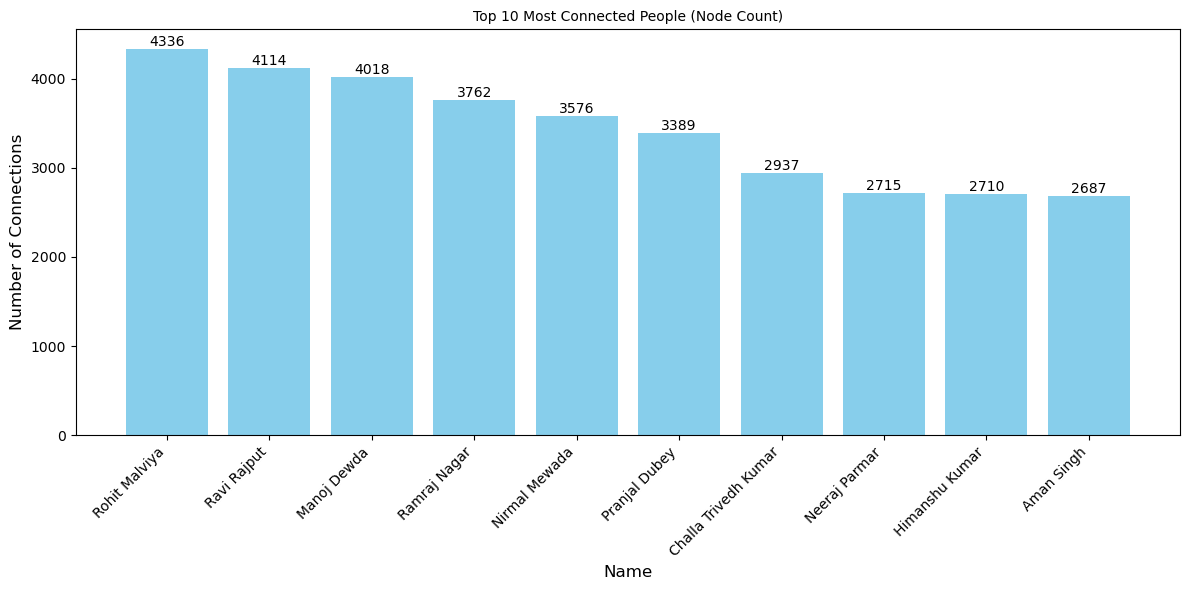

In [37]:
import json
import matplotlib.pyplot as plt

# Load the node counts from JSON file
with open("node_counts.json", "r", encoding="utf-8") as f:
    node_counts = json.load(f)

# Sort by number of connections in descending order
sorted_counts = sorted(node_counts.items(), key=lambda x: x[1], reverse=True)

# Get top 10 entries
top_10 = sorted_counts[:10]
names = [item[0] for item in top_10]
counts = [item[1] for item in top_10]

# Plotting the bar chart
plt.figure(figsize=(12,6))
bars = plt.bar(names, counts, color='skyblue')
plt.xlabel("Name", fontsize=12)
plt.ylabel("Number of Connections", fontsize=12)
plt.title("Top 10 Most Connected People (Node Count)", fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate bars with count
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(count),
             ha='center', va='bottom', fontsize=10)

# Show the plot
plt.show()


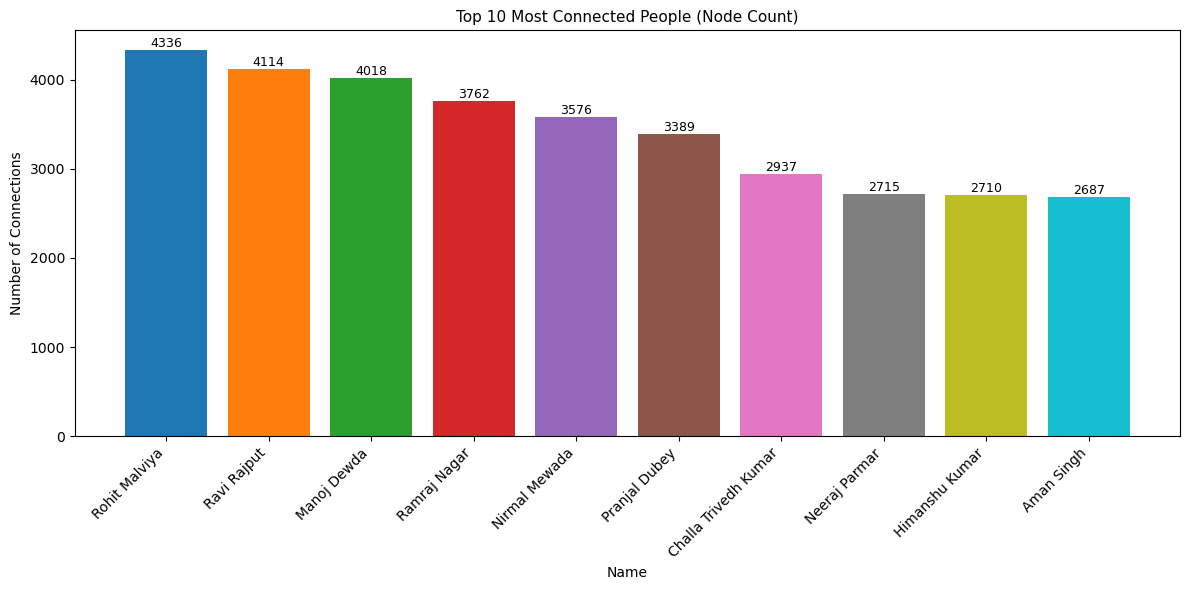

In [31]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the node counts from JSON file
with open("node_counts.json", "r", encoding="utf-8") as f:
    node_counts = json.load(f)

# Sort by number of connections in descending order
sorted_counts = sorted(node_counts.items(), key=lambda x: x[1], reverse=True)

# Get top 10 entries
top_10 = sorted_counts[:10]
names = [item[0] for item in top_10]
counts = [item[1] for item in top_10]

# Define a colormap for unique colors
colors = plt.cm.get_cmap('tab10', len(names))  # You can also try 'Set3', 'tab20', etc.

# Plotting the colorful bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(names, counts, color=[colors(i) for i in range(len(names))])
plt.xlabel("Name", fontsize=10)
plt.ylabel("Number of Connections", fontsize=10)
plt.title("Top 10 Most Connected People (Node Count)", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate bars with count
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(count),
             ha='center', va='bottom', fontsize=9)

# Show the plot
plt.show()


## linkdin Connection range 

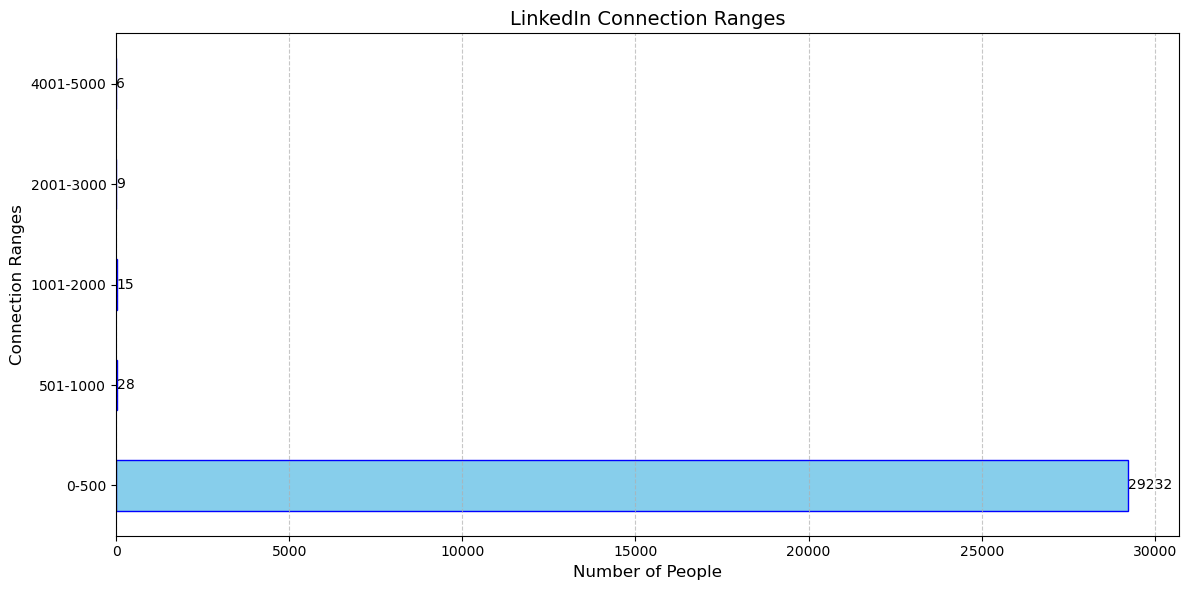

In [32]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load JSON data
with open("node_counts.json", "r") as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(list(data.items()), columns=["Name", "ConnectionCount"])

# Define your custom connection ranges
bins = [0, 500, 1000, 2000, 3000, 5000]
labels = ['0-500', '501-1000', '1001-2000', '2001-3000', '4001-5000']

# Assign each person to a range
df['Range'] = pd.cut(df['ConnectionCount'], bins=bins, labels=labels, right=True)

# Count how many fall into each range
range_counts = df['Range'].value_counts().sort_index()

# --- Horizontal Bar Chart ---
plt.figure(figsize=(12, 6))
range_counts.plot(kind='barh', color='skyblue', edgecolor='blue')

plt.title('LinkedIn Connection Ranges', fontsize=14)
plt.xlabel('Number of People', fontsize=12)
plt.ylabel('Connection Ranges', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add numbers on bars
for index, value in enumerate(range_counts):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()


## employeed and unemployeed Estimation 

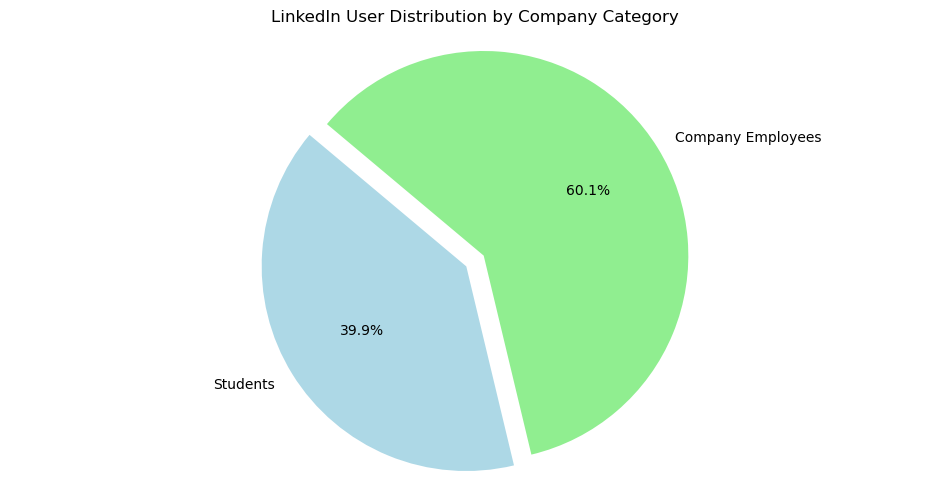


Counts:
Students: 44345
Company Employees: 66922


In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Folder path
folder_path = "LinkedIn Data Public"

# Counters
student_count = 0
company_count = 0

# Loop through all files in folder
for filename in os.listdir(folder_path):
    if filename.endswith(".csv") or filename.endswith(".xlsx"):
        file_path = os.path.join(folder_path, filename)
        
        try:
            if filename.endswith(".csv"):
                df = pd.read_csv(file_path)
            else:
                df = pd.read_excel(file_path)

            if 'name' in df.columns and 'company' in df.columns:
                for company in df['company'].astype(str):
                    company_lower = company.lower().strip()

                    # If company is blank (represents student)
                    if company_lower in ["", "nan", "none"]:
                        student_count += 1
                    else:
                        company_count += 1
        except Exception as e:
            print(f"Error reading {filename}: {e}")

# Pie chart data
labels = ['Students', 'Company Employees']
counts = [student_count, company_count]
colors = ['lightblue', 'lightgreen']

# Pie Chart
plt.figure(figsize=(12,6))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, explode=(0.05, 0.05))
plt.title("LinkedIn User Distribution by Company Category")
plt.axis('equal')
plt.show()

# Print raw counts
print(f"\nCounts:\nStudents: {student_count}\nCompany Employees: {company_count}")


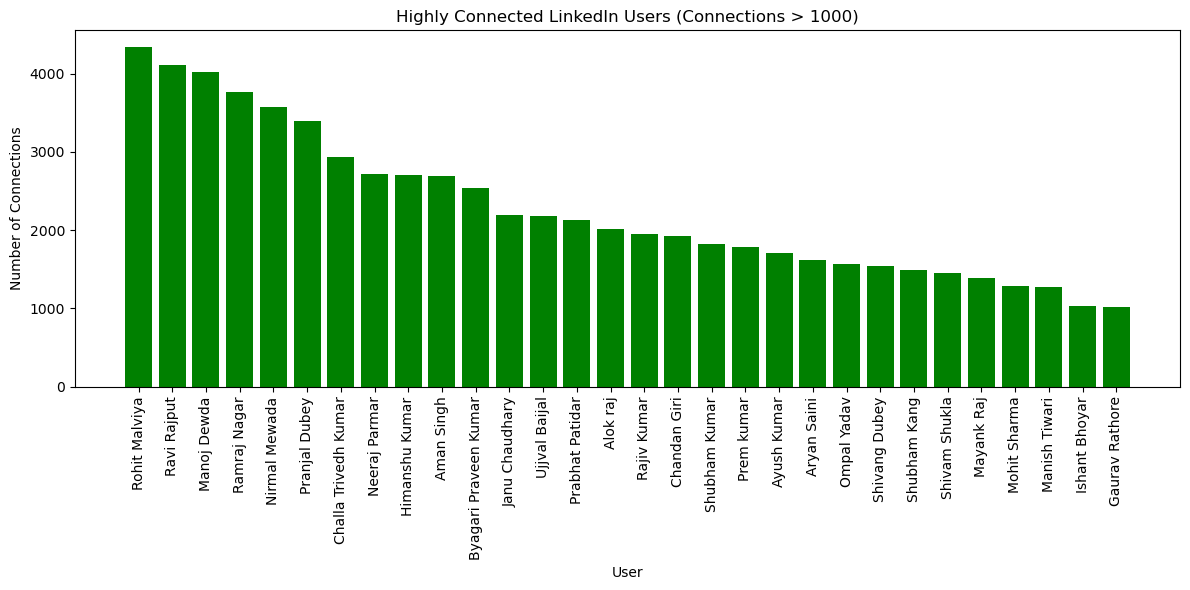

Highly Connected Users (Descending Order):
Rohit Malviya: 4336 connections
Ravi Rajput: 4114 connections
Manoj Dewda: 4018 connections
Ramraj Nagar: 3762 connections
Nirmal Mewada: 3576 connections
Pranjal Dubey: 3389 connections
Challa Trivedh Kumar: 2937 connections
Neeraj Parmar: 2715 connections
Himanshu Kumar: 2710 connections
Aman Singh: 2687 connections
Byagari Praveen Kumar: 2538 connections
Janu Chaudhary: 2191 connections
Ujjval Baijal: 2184 connections
Prabhat Patidar: 2131 connections
Alok raj: 2017 connections
Rajiv Kumar: 1949 connections
Chandan Giri: 1931 connections
Shubham Kumar: 1823 connections
Prem kumar: 1781 connections
Ayush Kumar: 1713 connections
Aryan Saini: 1619 connections
Ompal Yadav: 1573 connections
Shivang Dubey: 1539 connections
Shubham Kang: 1489 connections
Shivam Shukla: 1449 connections
Mayank Raj: 1387 connections
Mohit Sharma: 1283 connections
Manish Tiwari: 1271 connections
Ishant Bhoyar: 1030 connections
Gaurav Rathore: 1019 connections


In [34]:
import json
import matplotlib.pyplot as plt

# Load data
with open("node_counts.json", "r") as file:
    adjacency_list = json.load(file)

# Filter users with >1000 connections
highly_connected = {name: count for name, count in adjacency_list.items() if count > 1000}

# Sort by count descending
sorted_highly_connected = dict(sorted(highly_connected.items(), key=lambda item: item[1], reverse=True))

# Plotting
plt.figure(figsize=(12,6))
plt.bar(sorted_highly_connected.keys(), sorted_highly_connected.values(), color='green')
plt.xticks(rotation=90)
plt.title("Highly Connected LinkedIn Users (Connections > 1000)")
plt.xlabel("User")
plt.ylabel("Number of Connections")
plt.tight_layout()
plt.show()

# Print for reference
print("Highly Connected Users (Descending Order):")
for name, count in sorted_highly_connected.items():
    print(f"{name}: {count} connections")


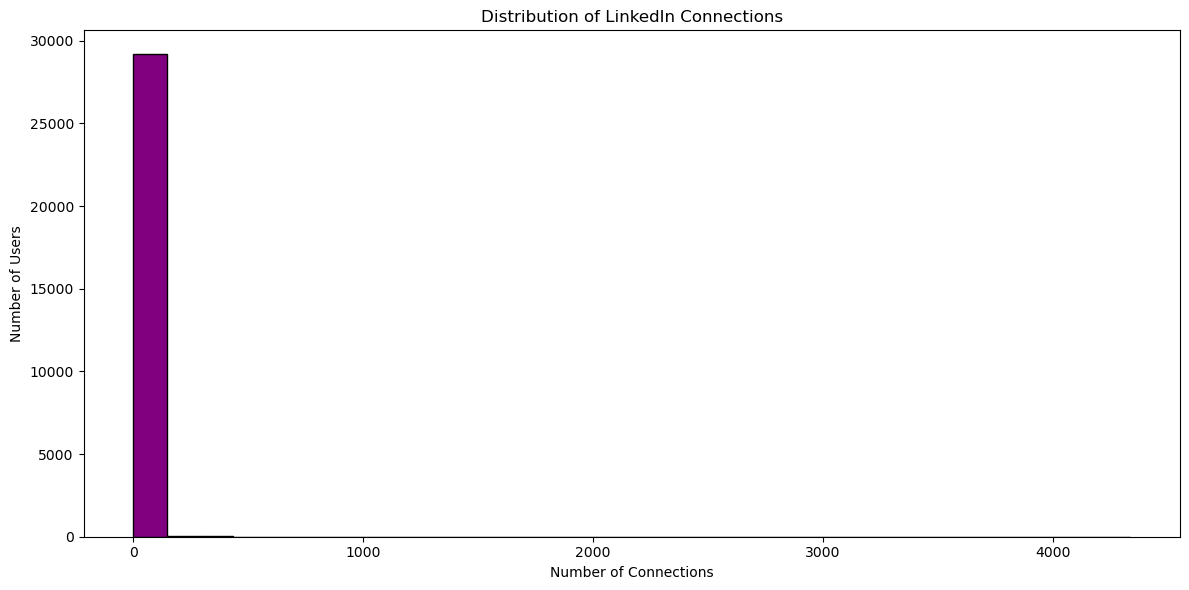

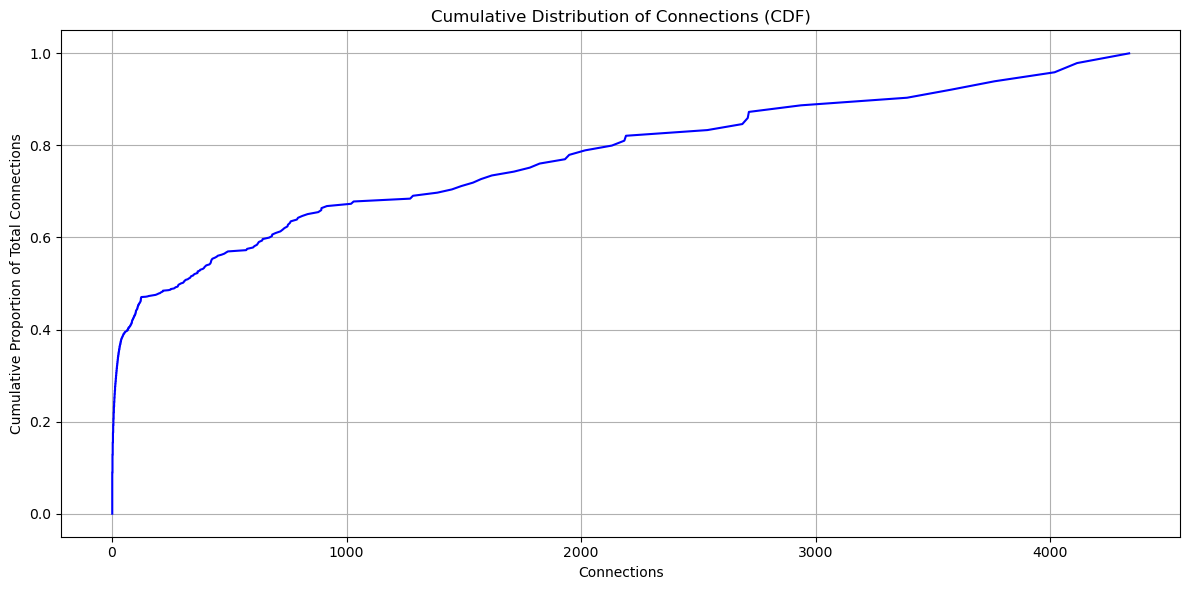

In [35]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load your LinkedIn adjacency list
with open("node_counts.json", "r") as file:
    adjacency_list = json.load(file)

names = list(adjacency_list.keys())
connections = list(adjacency_list.values())


# 1. CONNECTION DISTRIBUTION (HISTOGRAM)

plt.figure(figsize=(12,6))
plt.hist(connections, bins=30, color='purple', edgecolor='black')
plt.title("Distribution of LinkedIn Connections")
plt.xlabel("Number of Connections")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

# 2. CUMULATIVE DISTRIBUTION FUNCTION (CDF)

sorted_conn = np.sort(connections)
cdf = np.cumsum(sorted_conn) / sum(sorted_conn)

plt.figure(figsize=(12,6))
plt.plot(sorted_conn, cdf, color='blue')
plt.title("Cumulative Distribution of Connections (CDF)")
plt.xlabel("Connections")
plt.ylabel("Cumulative Proportion of Total Connections")
plt.grid(True)
plt.tight_layout()
plt.show()



